# Urban Heat & Vegetation Analysis
### Sample Workbook

This workbook serves as a sample for the user to walk through the process to evaluate a city's urban thermal and vegetative properties. Use this workbook as an example of the tools built as a part of this project.

First install the dependencies. A dictionary of some sample cities has been provided for convenience.

In [ ]:
# Import Generic Libraries
import pickle
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
from matplotlib import pyplot as plt

# Import Custom Modules
from observation_classes.combined_observation import CombinedObservation
from utils.calculate_obs_stats import calculate_index_stats, mask_pairing, calc_iou_thresholds, temp_hist
from operations.collect_multiple_observations import complete_report
from operations.stats_for_multiple_cities import best_iou_thresholds, complete_statistical_analysis


# Set Global Variables
CITY_SHORTLIST={
    'washington_dc': 4140963,
    'rio': 3451190,
    'tokyo': 1850147,
    'stockholm': 2673730,
    'nairobi': 184745,
    'casablanca': 2553604,
    'sydney': 2147714,
}

Create an Observation titled "obs". 

Replace the city name with any city name in the dictionary above to view different city types

In [2]:
city_name1 = "rio"
city_id1 = CITY_SHORTLIST[city_name1]
obs1 = CombinedObservation(city_id1, sqkm=300)

Observation collected on 2025-02-16 for landsat-c2-l2
Observation collected on 2024-11-18 for sentinel-2-l2a
Rio de Janeiro collection complete


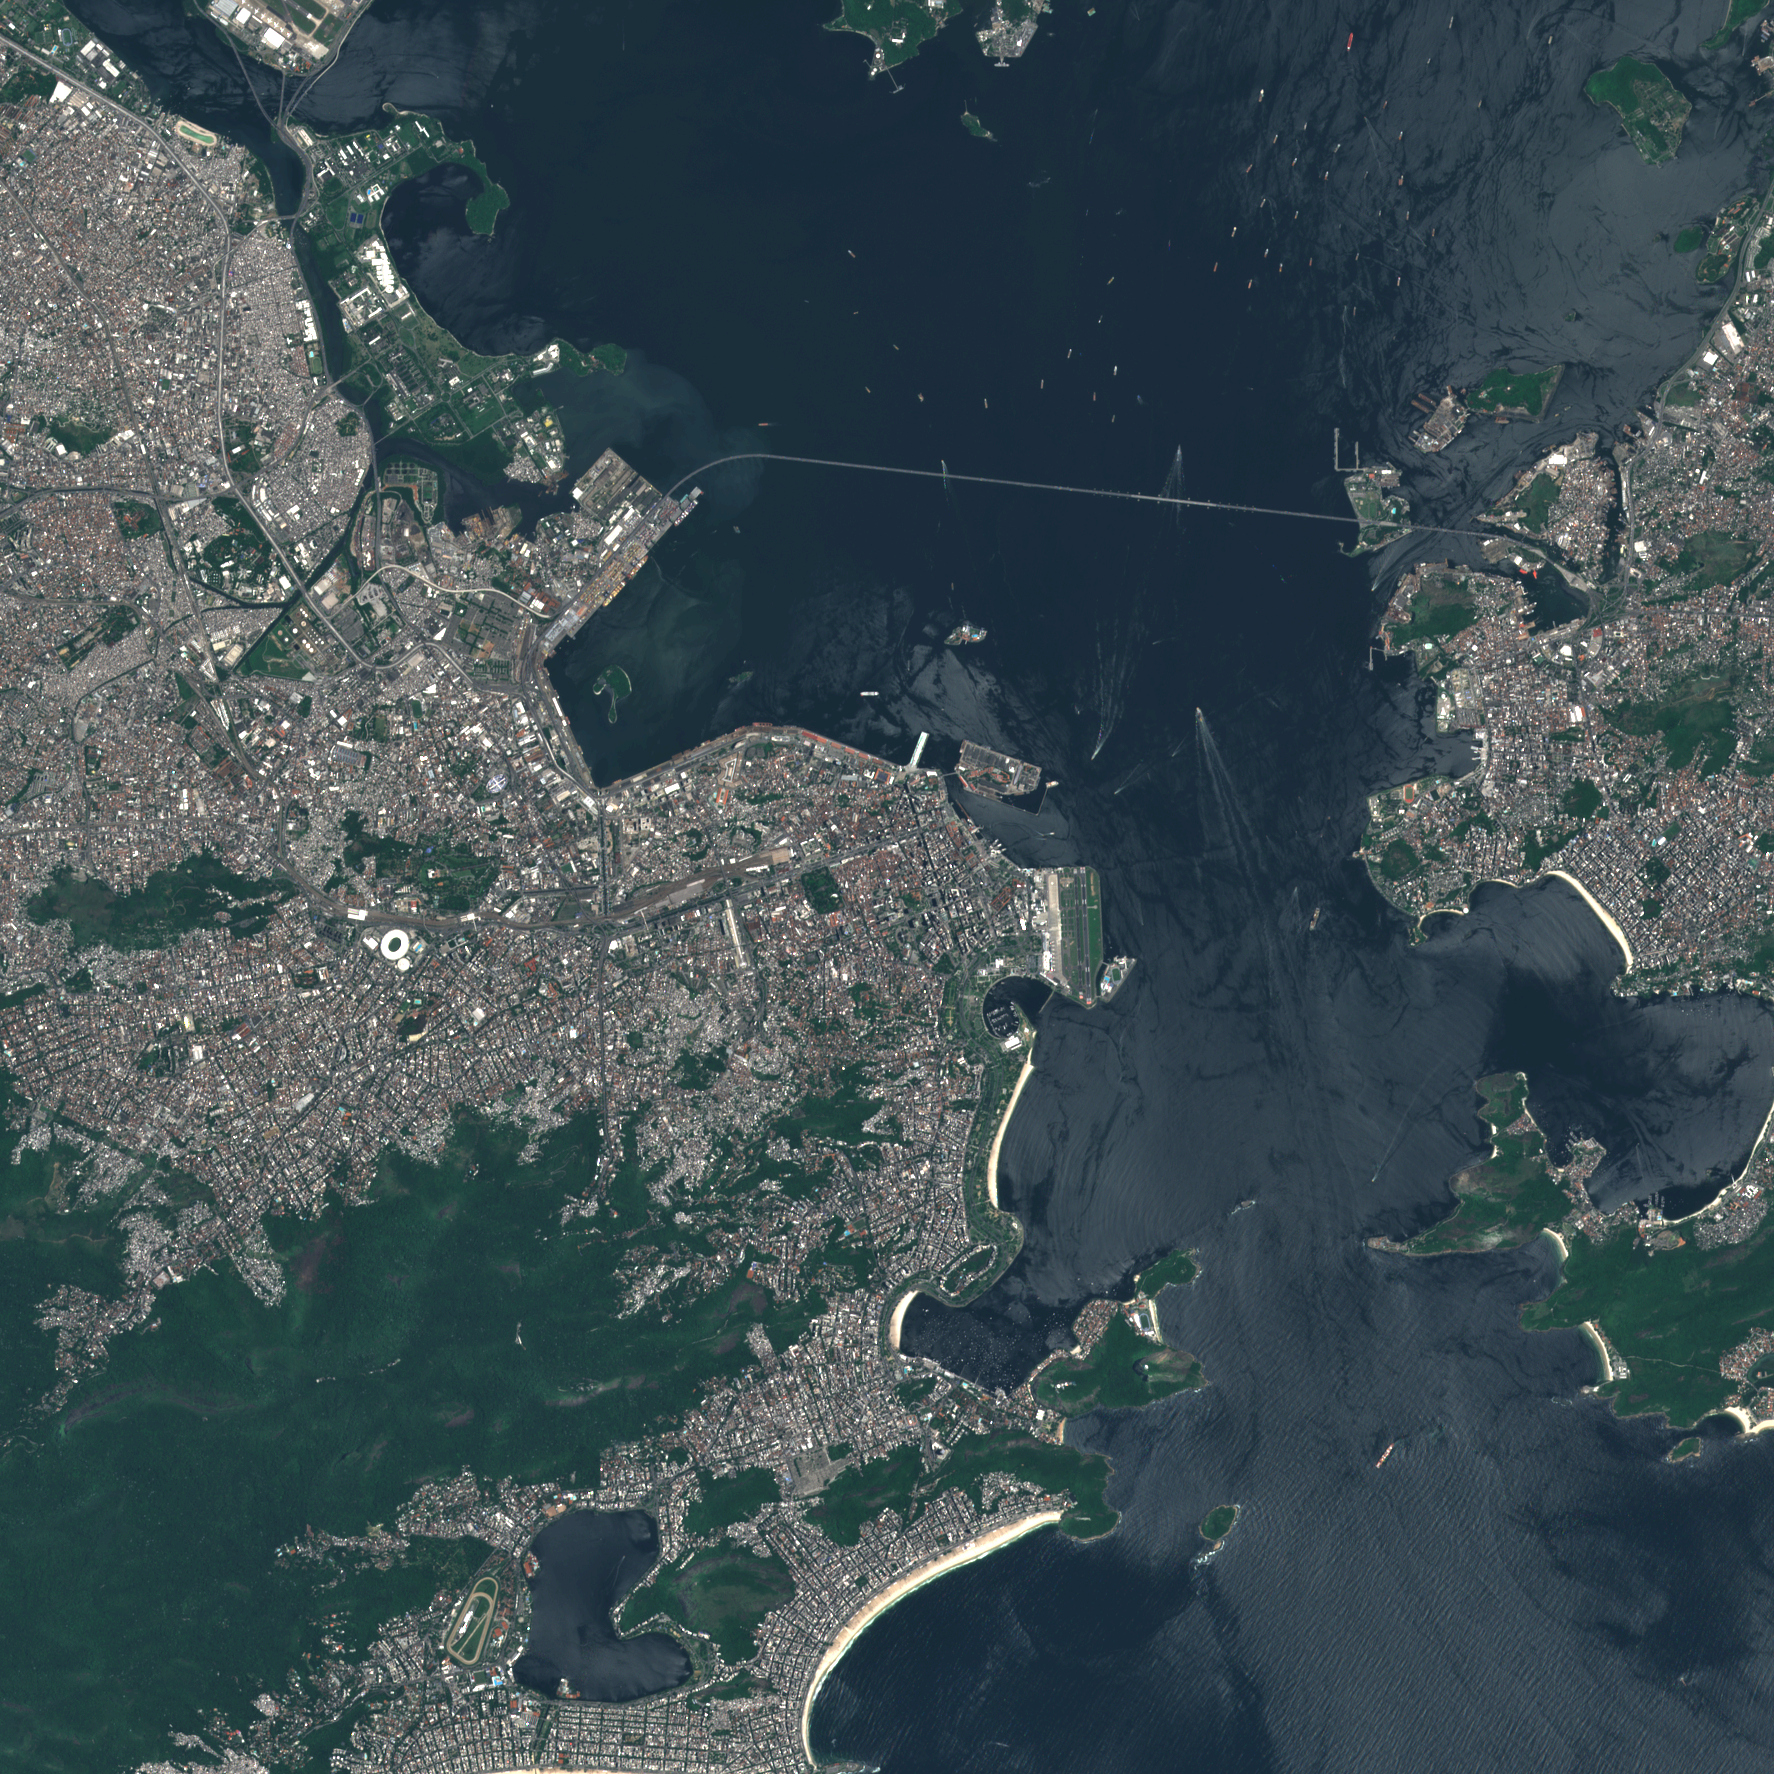

In [3]:
obs1.image

In [ ]:
def create_overlay(
    base_image: Image.Image,
    arr1: np.ndarray,
    arr2: np.ndarray,
    arr1_threshold=0.4,
    arr2_threshold=0.5,
    arr1_color=(255, 0, 0),      # Red
    arr2_color=(0, 0, 255),      # Blue
):
    """
    Overlay two arrays onto a PIL image.

    Parameters
    ----------
    base_image : PIL.Image
        Original satellite image.
    arr1 : np.ndarray
        Values between 0 and 1.
    arr2 : np.ndarray
        Any numeric range.
    """

    # Ensure RGBA
    base = base_image.convert("RGBA")
    h, w = arr1.shape

    if base.size != (w, h):
        raise ValueError(
            f"Image size {base.size} does not match array shape {(h, w)}"
        )

    # --------------------------------------------------
    # ARR1 OVERLAY
    # --------------------------------------------------

    arr1_alpha = np.zeros_like(arr1, dtype=np.uint8)

    mask1 = arr1 > arr1_threshold

    if mask1.any():
        # Normalize values above threshold to 0-255
        arr1_norm = (arr1[mask1] - arr1_threshold) / (
            arr1.max() - arr1_threshold
        )

        arr1_alpha[mask1] = (arr1_norm * 255).astype(np.uint8)

    overlay1 = np.zeros((h, w, 4), dtype=np.uint8)
    overlay1[..., 0] = arr1_color[0]
    overlay1[..., 1] = arr1_color[1]
    overlay1[..., 2] = arr1_color[2]
    overlay1[..., 3] = arr1_alpha

    overlay1_img = Image.fromarray(overlay1, mode="RGBA")

    # --------------------------------------------------
    # ARR2 OVERLAY
    # --------------------------------------------------

    arr2_alpha = np.zeros_like(arr2, dtype=np.uint8)

    mask2 = arr2 > arr2_threshold

    if mask2.any():
        # Normalize values above threshold to 0-255
        arr2_norm = (arr2[mask2] - arr2_threshold) / (
            arr2.max() - arr2_threshold
        )

        arr1_alpha[mask1] = (arr1_norm * 255).astype(np.uint8)

    overlay2 = np.zeros((h, w, 4), dtype=np.uint8)
    overlay2[..., 0] = arr2_color[0]
    overlay2[..., 1] = arr2_color[1]
    overlay2[..., 2] = arr2_color[2]
    overlay2[..., 3] = arr2_alpha

    overlay2_img = Image.fromarray(overlay2, mode="RGBA")

    # --------------------------------------------------
    # COMPOSITE
    # --------------------------------------------------

    result = Image.alpha_composite(base, overlay1_img)
    result2 = Image.alpha_composite(result, overlay2_img)

    return result2



def resize_array(arr: np.ndarray, target_shape):
    """
    Resize a 2D numpy array to (height, width).
    """
    target_h, target_w = target_shape

    arr_img = Image.fromarray(arr.astype(np.float32))
    arr_resized = arr_img.resize((target_w, target_h), Image.Resampling.BILINEAR)

    return np.array(arr_resized)

In [41]:
base_img = obs1.image
arr1 = obs1.ndvi.to_numpy().squeeze()
arr2 = obs1.lst.to_array().to_numpy().squeeze()


base = base_img.convert("RGBA")
img_w, img_h = base.size

arr1 = resize_array(arr1, (img_h, img_w))
arr2 = resize_array(arr2, (img_h, img_w))

In [43]:
arr2 = arr2/np.nanmax(arr2)

In [48]:
result = create_overlay(
    base_img,
    arr2,
    arr2,
    arr1_threshold=0.4,
    arr2_threshold=0.5,
    arr1_color=(0, 255, 0),   # green
    arr2_color=(255, 0, 0), # red
)

result.show()
result.save("overlay.png")

In [45]:
arr2

array([[0.7581216 , 0.7581213 , 0.7579529 , ..., 0.57260877, 0.5697842 ,
        0.56977946],
       [0.75812024, 0.75811994, 0.75795126, ..., 0.5726044 , 0.5697803 ,
        0.5697755 ],
       [0.75731593, 0.7573153 , 0.7569594 , ..., 0.57000357, 0.56746036,
        0.56745607],
       ...,
       [0.5562146 , 0.5562131 , 0.5553155 , ..., 0.44741407, 0.44705862,
        0.44705802],
       [0.5562146 , 0.5562129 , 0.55520296, ..., 0.447414  , 0.44707727,
        0.4470767 ],
       [0.5562146 , 0.5562129 , 0.5552028 , ..., 0.447414  , 0.4470773 ,
        0.44707677]], shape=(1774, 1774), dtype=float32)